# Fine-tuning CNN Virus model for YFV: Train

## Objectives and Plan

**Overall plan**: use 50-mer simreads from specificly selected 5 YFV reference sequences to fine tune the CNN Virus model. The reference sequences are selected as progressively distant from the training reference sequence.

**In the notebook**:
- create the fasta file with 5 reference sequences
- create the 50-mer simreads from these sequences
- test the model training with a few epochs

List of 5 reference sequences accession:
- KU978763: West African II : Nigeria 1946
- AY968064: Angolan : Angola 1971
- JN620362: East-Central African Uganda 2010
- MF370549: South american I : Brazil 2015
- MF004382: South american II : Bolivia 1999

*Reference*:

<details>
  <summary>Email Nicolas Berthet Dec 13, 2024</summary>
  <p>Comme la séquence de référence qui a été utilisé pour entrainer le modèle était celle du vaccin 17D, qui appartient au clade West African II, je propose d’utiliser les séquences ci-dessous :</p>
  <ul>
    <li>West African II : Nigeria 1946 KU978763</li>
    <li>Angolan : Angola 1971 AY968064</li>
    <li>East-Central African Uganda 2010 JN620362</li>
    <li>South american I : Brazil 2015 MF370549</li>
    <li>South american II : Bolivia 1999 MF004382</li>
  </ul>
  <p>L’idée d’entrainer avec une nouvelle séquence à chaque fois ? Et de voir si on couvre la totalité du génome ?</p>
  <p>Bon weekend</p>
  <p>Amicalement</p>
  <p>Nicolas</p>
</details>

# 1. Imports and setup environment

In [ ]:
# Install required custom packages if not installed yet.
import importlib.util
if not importlib.util.find_spec('eccore'):
    print('installing package: `eccore`')
    ! pip install -qqU eccore
else:
    print('`eccore` already installed')
if not importlib.util.find_spec('metagentorch'):
    print('installing package: `metagentorch')
    ! pip install -qqU metagentorch
else:
    print('`metagentorch` already installed')

`eccore` already installed
`metagentorch` already installed


In [ ]:
# Import all required packages
import os
from datetime import datetime, timedelta
from functools import partial
from pathlib import Path
from pprint import pprint
from typing import Any, Dict, Generator, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from eccore.core import files_in_tree, get_config_value
from eccore.ipython import nb_setup
from nbdev import show_doc
from tqdm.notebook import tqdm, trange

# Setup the notebook for development
nb_setup()

os.environ['KERAS_BACKEND'] = "torch"
import keras
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

from metagentorch.art import ArtIllumina
from metagentorch.cnn_virus.architecture import create_model_original
from metagentorch.cnn_virus.data import AlnFileReader,TextFileDataset, OriginalLabels
from metagentorch.core import ProjectFileSystem, list_available_devices, TextFileBaseReader

Set autoreload mode


List all computing devices available on the machine

In [ ]:
list_available_devices()

CUDA available: True
Number of CUDA devices: 1
CUDA Device 0: NVIDIA GeForce GTX 1050
CPU available: cpu


# 2. Setup paths to files

Key folders and system information

In [ ]:
pfs = ProjectFileSystem()
pfs.info()

Running linux on local computer
Device's home directory: /home/vtec
Project file structure:
 - Root ........ /home/vtec/projects/bio/metagentorch 
 - Data Dir .... /home/vtec/projects/bio/metagentorch/data 
 - Notebooks ... /home/vtec/projects/bio/metagentorch/nbs


Set the path to the pretained model and the virus labels mapping file:

- `p2model`: path to file with saved original pretrained model
- `p2virus_labels` path to file with virus names and labels mapping for original model

In [ ]:
p2model = pfs.data / 'saved/cnn_virus_original/pretrained_model.h5'
assert p2model.is_file(), f"No file found at {p2model.absolute()}"

p2virus_labels = pfs.data / 'CNN_Virus_data/virus_name_mapping'
assert p2virus_labels.is_file(), f"No file found at {p2virus_labels.absolute()}"

In [ ]:
p2simreads = pfs.data / 'ncbi/simreads/yf'
p2finetune_fq = p2simreads / f"single_finetune_5seq_50bp/single_finetune_5seq_50bp.fq"
p2finetune_aln = p2simreads / f"single_finetune_5seq_50bp/single_finetune_5seq_50bp.aln"
assert p2finetune_fq.is_file() and p2finetune_aln.is_file()

# 3. Load and prepare model for finetuning

Load the original model with parameters

In [ ]:
model = create_model_original()
model.summary()

Creating CNN Model (Original)
Loading parameters from pretrained_model.h5
Created pretrained model
Model will run on: cuda


Model: "CNN_Virus"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input-seq           │ (None, 50, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv-1 (Conv1D)     │ (None, 50, 512)   │     13,312 │ input-seq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn-1                │ (None, 50, 512)   │      2,048 │ conv-1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool-1           │ (None, 25, 512)   │          0 │ bn-1[0][0]        │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv-2 (Conv1D)     │ (None, 25, 512)   │  1,311,232 │ maxpool-1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn-2                │ (None, 25, 512)   │      2,048 │ conv-2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool-2           │ (None, 13, 512)   │          0 │ bn-2[0][0]        │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv-3 (Conv1D)     │ (None, 13, 1024)  │  3,671,040 │ maxpool-2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv-4 (Conv1D)     │ (None, 13, 1024)  │  7,341,056 │ conv-3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn-3                │ (None, 13, 1024)  │      4,096 │ conv-4[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool-3           │ (None, 7, 1024)   │          0 │ bn-3[0][0]        │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 7168)      │          0 │ maxpool-3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense-1 (Dense)     │ (None, 1024)      │  7,341,056 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn-4                │ (None, 1024)      │      4,096 │ dense-1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ do-1 (Dropout)      │ (None, 1024)      │          0 │ bn-4[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ labels (Dense)      │ (None, 187)       │    191,675 │ do-1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 1211)      │          0 │ do-1[0][0],       │
│ (Concatenate)       │                   │            │ labels[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense-2 (Dense)     │ (None, 1024)      │  1,241,088 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn-5                │ (None, 1024)      │      4,096 │ dense-2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos (Dense)         │ (None, 10)        │     10,250 │ bn-5[0][0]      

 Total params: 21,137,093 (80.63 MB)

 Trainable params: 21,128,901 (80.60 MB)

 Non-trainable params: 8,192 (32.00 KB)

Review trainable parameters for each layer

In [ ]:
print('\n'.join([f"{i:2d}:  {l.name:10s} is trainable: {l.trainable}" for i,l in enumerate(model.layers)]))

 0:  input-seq  is trainable: True
 1:  conv-1     is trainable: True
 2:  bn-1       is trainable: True
 3:  maxpool-1  is trainable: True
 4:  conv-2     is trainable: True
 5:  bn-2       is trainable: True
 6:  maxpool-2  is trainable: True
 7:  conv-3     is trainable: True
 8:  conv-4     is trainable: True
 9:  bn-3       is trainable: True
10:  maxpool-3  is trainable: True
11:  flatten    is trainable: True
12:  dense-1    is trainable: True
13:  bn-4       is trainable: True
14:  do-1       is trainable: True
15:  labels     is trainable: True
16:  concat     is trainable: True
17:  dense-2    is trainable: True
18:  bn-5       is trainable: True
19:  pos        is trainable: True


Protect key layers of the original model:
- Make all feature extraction features no trainable to protect the original model.
- Make dense layers after the flatten layer as trainable for fine tuning

In [ ]:
for l in model.layers[:12]:
    l.trainable = False
print('\n'.join([f"{i:2d}:  {l.name:10s} is trainable: {l.trainable}" for i,l in enumerate(model.layers)]))

 0:  input-seq  is trainable: False
 1:  conv-1     is trainable: False
 2:  bn-1       is trainable: False
 3:  maxpool-1  is trainable: False
 4:  conv-2     is trainable: False
 5:  bn-2       is trainable: False
 6:  maxpool-2  is trainable: False
 7:  conv-3     is trainable: False
 8:  conv-4     is trainable: False
 9:  bn-3       is trainable: False
10:  maxpool-3  is trainable: False
11:  flatten    is trainable: False
12:  dense-1    is trainable: True
13:  bn-4       is trainable: True
14:  do-1       is trainable: True
15:  labels     is trainable: True
16:  concat     is trainable: True
17:  dense-2    is trainable: True
18:  bn-5       is trainable: True
19:  pos        is trainable: True


# 4. Train frozen model

In [ ]:
from keras.optimizers import Adam                                   # type: ignore
from keras.losses import CategoricalCrossentropy                    # type: ignore
from keras.metrics import CategoricalAccuracy, Recall, Precision    # type: ignore
from keras.callbacks import EarlyStopping, ModelCheckpoint          # type: ignore  

In [ ]:
p2finetuning_ds = pfs.data / 'ncbi/ds/yf/finetuning'
assert p2finetuning_ds.is_dir()
p2finetune_train_ds = p2finetuning_ds / '50mers_ds_training'
p2finetune_val_ds = p2finetuning_ds / '50mers_ds_validation'
p2finetune_test_ds = p2finetuning_ds / '50mers_ds_test'

assert p2finetune_train_ds.is_file() and p2finetune_val_ds.is_file() and p2finetune_test_ds.is_file()

Define the nbr of steps per epoch for training and and nbr of step for validation:

In [ ]:
p2sizes = p2finetuning_ds / 'dataset-sizes.cfg'
nb_train_samples = int(get_config_value('NB SAMPLES', '50mers_ds_training', p2sizes))
nb_val_samples = int(get_config_value('NB SAMPLES', '50mers_ds_validation', p2sizes))
nb_train_samples, nb_val_samples

Using config file at /home/vtec/projects/bio/metagentorch/data/ncbi/ds/yf/finetuning/dataset-sizes.cfg
Using config file at /home/vtec/projects/bio/metagentorch/data/ncbi/ds/yf/finetuning/dataset-sizes.cfg


(390150, 43350)

After experiment on my local machine (1 epoch for the full training set with validation) one epoch takes about 26 min total time

|Experiment | Nb epochs | Duration | Time/epoch | lr |  val_labels_acc | val_loss |
| --- |:---:|:---:|:---:|:---:|:---:|:---:|
|March 2, 22h| 8 | 3h30 | 26 min | 1e-4 | 0.9491 | 0.4032 |
|March 3, 8h| 15 out of 25 | 9h30  | 22 min | 1e-4 | 0.9570 | 0.3617  |
|March 3, 23h| 25 out of 25 | 7h16  | 17 min | 1e-4 | 0.9777 | 0.1655 |

In [ ]:
nb_epochs = 25
print(f"Estimated time: {int(26/60 * nb_epochs):,d} hours")

Estimated time: 10 hours


In [ ]:
lr = 1e-4
bs_train = 512
bs_val = 2048

ds_train = TextFileDataset(p2finetune_train_ds)
dl_train = DataLoader(ds_train, batch_size=bs_train, shuffle=False, pin_memory=True, drop_last=True)

ds_val = TextFileDataset(p2finetune_val_ds)
dl_val = DataLoader(ds_val, batch_size=bs_val, shuffle=False, pin_memory=True, drop_last=True)

loss = CategoricalCrossentropy(name='crossentropy')
lbl_acc, pos_acc = CategoricalAccuracy(name='acc'),CategoricalAccuracy(name='acc')

model = create_model_original()

model.compile(
    optimizer=Adam(learning_rate=lr),
    loss=loss,
    metrics=[lbl_acc, pos_acc],
)

Creating CNN Model (Original)
Loading parameters from pretrained_model.h5
Created pretrained model
Model will run on: cuda


In [ ]:
print(f"Each epoch should run {nb_train_samples//bs_train} steps/batches for each epoch")
print(f"Validation will take {nb_val_samples//bs_val} steps/batches")

print(f"Parameters: \n{nb_epochs} epochs \n{lr:.0000e} learning rate")

Each epoch should run 762 steps/batches for each epoch
Validation will take 21 steps/batches
Parameters: 
25 epochs 
1e-04 learning rate


In [ ]:
%%time
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

hist = model.fit(
    dl_train, 
    epochs=nb_epochs,
    # steps_per_epoch=nb_steps_per_epoch,
    validation_data=dl_val,
    validation_steps=nb_val_samples // bs_val,
    shuffle=False,
    callbacks=[es],
    verbose=1,
    )

Epoch 1/25
    762/Unknown 1072s 1s/step - labels_acc: 0.7016 - labels_loss: 3.3664 - loss: 7.5153 - pos_acc: 0.5909 - pos_loss: 4.1489

/home/vtec/miniconda3/envs/torch/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


762/762 ━━━━━━━━━━━━━━━━━━━━ 1093s 1s/step - labels_acc: 0.7018 - labels_loss: 3.3642 - loss: 7.5125 - pos_acc: 0.5910 - pos_loss: 4.1483 - val_labels_acc: 0.9227 - val_labels_loss: 0.4132 - val_loss: 3.1845 - val_pos_acc: 0.6552 - val_pos_loss: 2.7713
Epoch 2/25
762/762 ━━━━━━━━━━━━━━━━━━━━ 1079s 1s/step - labels_acc: 0.9180 - labels_loss: 0.4038 - loss: 2.7396 - pos_acc: 0.6769 - pos_loss: 2.3357 - val_labels_acc: 0.9357 - val_labels_loss: 0.2801 - val_loss: 1.6852 - val_pos_acc: 0.7380 - val_pos_loss: 1.4051
Epoch 3/25
762/762 ━━━━━━━━━━━━━━━━━━━━ 1054s 1s/step - labels_acc: 0.9321 - labels_loss: 0.2775 - loss: 1.4541 - pos_acc: 0.7596 - pos_loss: 1.1766 - val_labels_acc: 0.9444 - val_labels_loss: 0.2106 - val_loss: 0.9683 - val_pos_acc: 0.7999 - val_pos_loss: 0.7577
Epoch 4/25
762/762 ━━━━━━━━━━━━━━━━━━━━ 1036s 1s/step - labels_acc: 0.9419 - labels_loss: 0.2069 - loss: 0.8643 - pos_acc: 0.8182 - pos_loss: 0.6574 - val_labels_acc: 0.9515 - val_labels_loss: 0.1711 - val_loss: 0.6661 

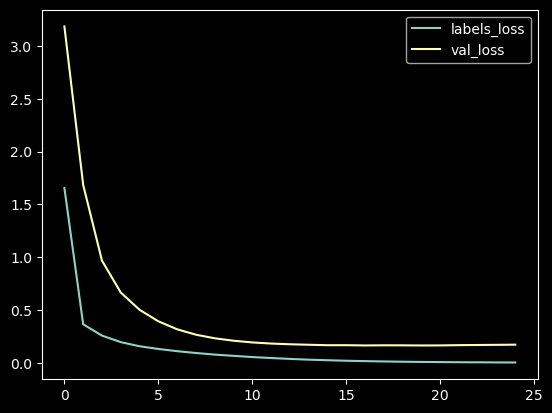

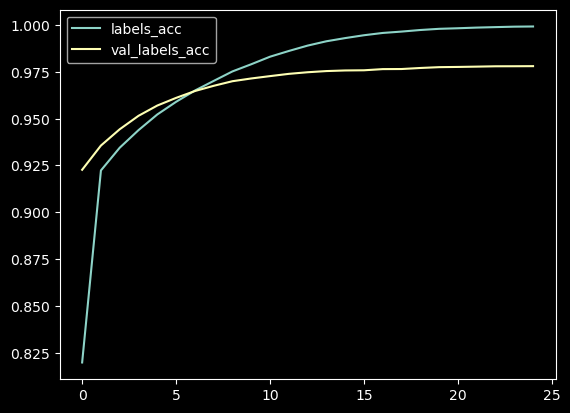

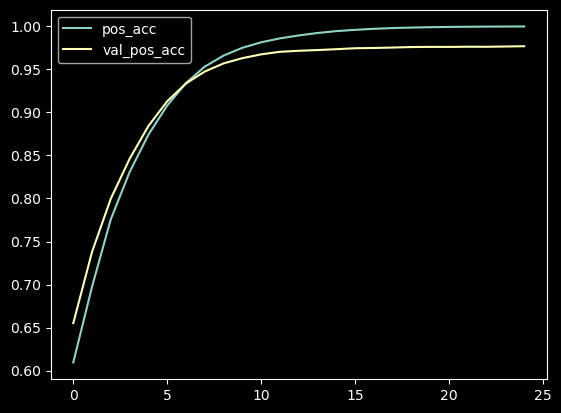

In [ ]:
first_idx = 0
pd.DataFrame(hist.history).iloc[first_idx:].loc[:, ['labels_loss', 'val_loss']].plot()
pd.DataFrame(hist.history).iloc[first_idx:].loc[:, ['labels_acc', 'val_labels_acc']].plot();
pd.DataFrame(hist.history).iloc[first_idx:].loc[:, ['pos_acc', 'val_pos_acc']].plot();

In [ ]:
p2finetuned_models = pfs.data / 'saved/cnn_virus_finetuned'
p2finetuned_models.is_dir()

hyperparams = f"lr_{lr}_epochs_{nb_epochs}"
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

model.save_weights(p2finetuned_models / f"yfv_5seq_{hyperparams}_{timestamp}.weights.h5")

In [ ]:
m2 = create_model_original(path2parameters=p2finetuned_models / f"yfv_5seq_{hyperparams}_{timestamp}.weights.h5")

Creating CNN Model (Original)
Loading parameters from yfv_5seq_lr_0.0001_epochs_25_20250303_233339.weights.h5
Created pretrained model
Model will run on: cuda


Test that the model is well loaded and evaluates at the same as the trained model.

During training: 
- val_loss: 0.3617 
- val_labels_loss: 0.1915 
- val_pos_loss: 0.1702
- val_labels_acc: 0.9570 
- val_pos_acc: 0.9561 

In [ ]:
p2sizes = p2finetuning_ds / 'dataset-sizes.cfg'
nb_test_samples = int(get_config_value('NB SAMPLES', '50mers_ds_test', p2sizes))
nb_test_samples

Using config file at /home/vtec/projects/bio/metagentorch/data/ncbi/ds/yf/finetuning/dataset-sizes.cfg


76500

In [ ]:
ds_test = TextFileDataset(p2finetune_test_ds)
dl_test = DataLoader(ds_test, batch_size=bs_val, shuffle=False, pin_memory=True, drop_last=True)

In [ ]:
m2.compile(
    optimizer=Adam(learning_rate=lr), 
    loss=loss, 
    metrics=[lbl_acc, pos_acc]
    )
res = m2.evaluate(
    dl_test, 
    steps=nb_test_samples // bs_val,
    )
print('Test Set Results')
print('\n'.join([f"{n:10s}: {r:.4f}" for n,r in zip('loss label_loss pos_loss label_acc pos_acc'.split(' '),res)]))

37/37 ━━━━━━━━━━━━━━━━━━━━ 26s 702ms/step - labels_acc: 0.9584 - labels_loss: 0.1968 - loss: 0.3821 - pos_acc: 0.9575 - pos_loss: 0.1853
Test Set Results
loss      : 0.3899
label_loss: 0.2028
pos_loss  : 0.1871
label_acc : 0.9582
pos_acc   : 0.9571
